In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\tusha\\Downloads\\archive (4)\\ObesityDataSet_raw_and_data_sinthetic.csv")
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.shape

(2111, 17)

In [4]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [5]:
df.nunique()

Age                               1402
Gender                               2
Height                            1574
Weight                            1525
CALC                                 4
FAVC                                 2
FCVC                               810
NCP                                635
SCC                                  2
SMOKE                                2
CH2O                              1268
family_history_with_overweight       2
FAF                               1190
TUE                               1129
CAEC                                 4
MTRANS                               5
NObeyesdad                           7
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

In [7]:
df.drop_duplicates()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.000000,Female,1.620000,64.000000,no,no,2.0,3.0,no,no,2.000000,yes,0.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
1,21.000000,Female,1.520000,56.000000,Sometimes,no,3.0,3.0,yes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,23.000000,Male,1.800000,77.000000,Frequently,no,2.0,3.0,no,no,2.000000,yes,2.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
3,27.000000,Male,1.800000,87.000000,Frequently,no,3.0,3.0,no,no,2.000000,no,2.000000,0.000000,Sometimes,Walking,Overweight_Level_I
4,22.000000,Male,1.780000,89.800000,Sometimes,no,2.0,1.0,no,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,Female,1.710730,131.408528,Sometimes,yes,3.0,3.0,no,no,1.728139,yes,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.982942,Female,1.748584,133.742943,Sometimes,yes,3.0,3.0,no,no,2.005130,yes,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524036,Female,1.752206,133.689352,Sometimes,yes,3.0,3.0,no,no,2.054193,yes,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.361936,Female,1.739450,133.346641,Sometimes,yes,3.0,3.0,no,no,2.852339,yes,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [8]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)
num_cols = df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE',
       'family_history_with_overweight', 'CAEC', 'MTRANS', 'NObeyesdad'],
      dtype='object')
Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')


# Target Variable Analysis

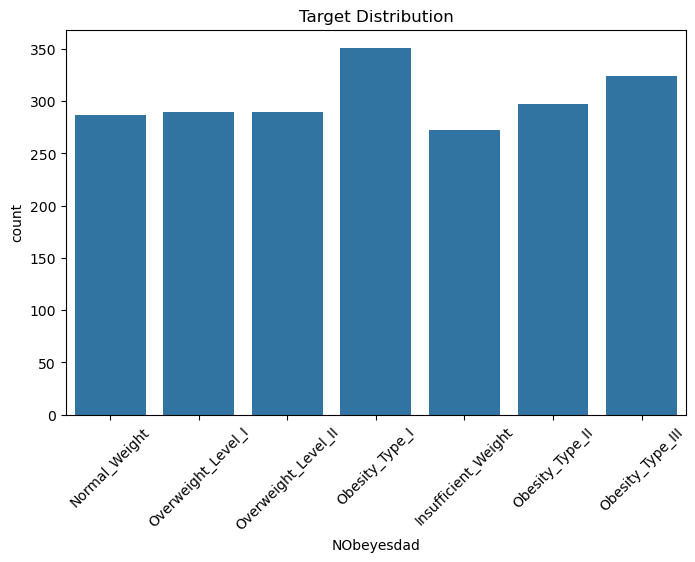

In [9]:
# Is data balanced or imbalanced?
plt.figure(figsize=(8,5))
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.title("Target Distribution")
plt.show()

# Check How Bad the Imbalance Is

In [10]:
df['NObeyesdad'].value_counts(normalize=True)*100
# this are mildly imbalance

NObeyesdad
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64

# Is there any multicollinearity

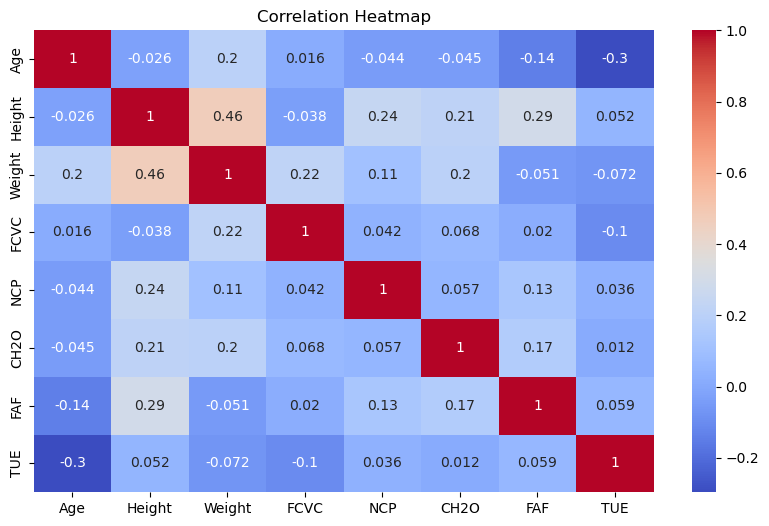

In [11]:
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
df['BMI'] = df['Weight']/ (df['Height'] ** 2)

In [13]:
df = df.drop(columns = ['Weight','Height'],axis=1)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   CALC                            2111 non-null   object 
 3   FAVC                            2111 non-null   object 
 4   FCVC                            2111 non-null   float64
 5   NCP                             2111 non-null   float64
 6   SCC                             2111 non-null   object 
 7   SMOKE                           2111 non-null   object 
 8   CH2O                            2111 non-null   float64
 9   family_history_with_overweight  2111 non-null   object 
 10  FAF                             2111 non-null   float64
 11  TUE                             2111 non-null   float64
 12  CAEC                            21

In [15]:
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

transformer = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# logistic Regression

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

pipe_lr = make_pipeline(
    transformer,
    LogisticRegression(max_iter=1000)
)

# knn

In [19]:
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = make_pipeline(
    transformer,
    KNeighborsClassifier(n_neighbors=5)
)

# Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = make_pipeline(
    transformer,
    DecisionTreeClassifier(max_depth=5)
)

# Random forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = make_pipeline(
    transformer,
    RandomForestClassifier(n_estimators=100)
)

# Train All Models

In [22]:
pipe_lr.fit(X_train, y_train)
pipe_knn.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE',
       'family_history_with_overweight', 'CAEC', 'MTRANS'],
      dtype='object'))])),
                ('randomforestclassifier', RandomForestClassifier())])

In [64]:
import warnings
warnings.filterwarnings("ignore")

# predict

In [24]:
y_pred_lr = pipe_lr.predict(X_test)
y_pred_knn = pipe_knn.predict(X_test)
y_pred_dt = pipe_dt.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

  File "C:\tusharinno\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\tusharinno\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\tusharinno\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\tusharinno\Lib\subprocess.py", line 1554, in _execute_child
    hp, ht

In [25]:
from sklearn.metrics import accuracy_score

print("LR:", accuracy_score(y_test, y_pred_lr))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("DT:", accuracy_score(y_test, y_pred_dt))
print("RF:", accuracy_score(y_test, y_pred_rf))

LR: 0.8888888888888888
KNN: 0.8226950354609929
DT: 0.966903073286052
RF: 0.9739952718676123


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        56
      Normal_Weight       0.92      0.98      0.95        62
     Obesity_Type_I       0.99      0.99      0.99        78
    Obesity_Type_II       0.98      0.98      0.98        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.98      0.89      0.93        56
Overweight_Level_II       0.96      0.98      0.97        50

           accuracy                           0.97       423
          macro avg       0.97      0.97      0.97       423
       weighted avg       0.97      0.97      0.97       423



# Confusion Matrix

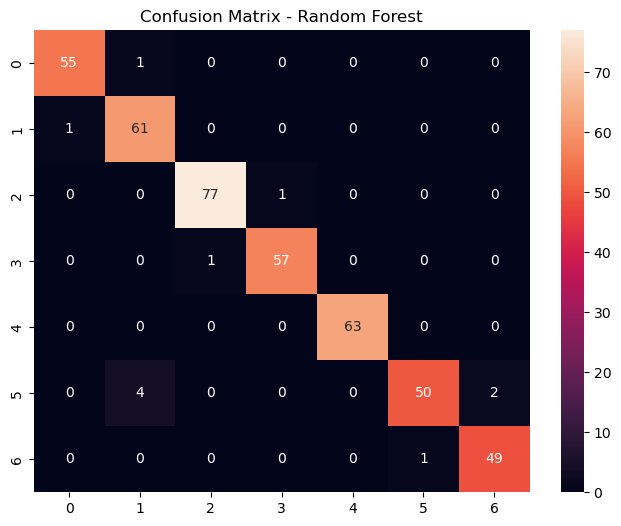

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Overfitting Check

In [28]:
print("Train Accuracy:", pipe_rf.score(X_train, y_train))
print("Test Accuracy:", pipe_rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9739952718676123


# Hyperparameter Tuning (GridSearchCV)

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [5, 10, 15],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    pipe_rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         Index(['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE',
       'family_history_with_overweight', 'CAEC', 'MTRANS'],
      dtype='object'))])),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [5, 10, 15],
                         'randomforestclassifier__min_samples_leaf': [1, 2, 4],
                         'randomforestclassifier__min_samples_split': [2, 5,
                                                                       10],
                         'randomforestclassifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [30]:
best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'randomforestclassifier__max_depth': 5, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 100}


# Create Final Random Forest Model

In [31]:
from sklearn.ensemble import RandomForestClassifier

final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Pipeline

In [32]:
from sklearn.pipeline import make_pipeline

final_pipe = make_pipeline(
    transformer,
    final_rf
)

# Train Final Model

In [33]:
final_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE',
       'family_history_with_overweight', 'CAEC', 'MTRANS'],
      dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=5, random_state=42))])

# Predictions

In [34]:
y_pred_final = final_pipe.predict(X_test)

# Final Evaluation

In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Final Accuracy: 0.91725768321513
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        56
      Normal_Weight       0.81      0.87      0.84        62
     Obesity_Type_I       0.99      0.94      0.96        78
    Obesity_Type_II       0.94      1.00      0.97        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.89      0.73      0.80        56
Overweight_Level_II       0.80      0.88      0.84        50

           accuracy                           0.92       423
          macro avg       0.91      0.91      0.91       423
       weighted avg       0.92      0.92      0.92       423



# Overfitting Check

In [36]:
print("Train Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy:", best_model.score(X_test, y_test))

Train Accuracy: 0.9520142180094787
Test Accuracy: 0.9243498817966903


# Gradient Boosting

##  pipeline


In [37]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import make_pipeline

pipe_gb = make_pipeline(
    transformer,
    GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    )
)

##  train & Evalute

In [38]:
pipe_gb.fit(X_train, y_train)

y_pred_gb = pipe_gb.predict(X_test)

from sklearn.metrics import accuracy_score
print("GB Accuracy:", accuracy_score(y_test, y_pred_gb))

GB Accuracy: 0.966903073286052


## Train vs Test Accuracy

In [54]:
print("GB Train:", pipe_gb.score(X_train, y_train))
print("GB Test :", pipe_gb.score(X_test, y_test))

GB Train: 1.0
GB Test : 0.966903073286052


# XGBoost

In [39]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.1/101.7 MB 17.3 MB/s eta 0:00:06
   -- ------------------------------------- 6.6/101.7 MB 17.7 MB/s eta 0:00:06
   --- ------------------------------------ 8.9/101.7 MB 15.4 MB/s eta 0:00:07
   ---- ----------------------------------- 10.5/101.7 MB 12.9 MB/s eta 0:00:08
   ---- ----------------------------------- 12.3/101.7 MB 12.3 MB/s eta 0:00:08
   ----- ---------------------------------- 14.2/101.7 MB 12.1 MB/s eta 0:00:08
   ------ --------------------------------- 15.7/101.7 MB 11.1 MB/s eta 0:00:08
   ------- -------------------------------- 17.8/101.7 MB 10.8 MB/s eta 0:00:08
   -------- ------------------------------- 20.4/101.7 MB 10.9 MB/s eta 0:00:08
   -------- ------------------------------- 22.8/101.7 MB 11.0 MB/s eta 0:00:08
   --------- ------------------------------ 25.2/101.7 MB 11.1 MB/s eta 0:00:07
   ---------- ----------------------------- 27.8/101

## Pipeline

In [40]:
from xgboost import XGBClassifier

pipe_xgb = make_pipeline(
    transformer,
    XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    )
)

# XGBoost does NOT accept string labels
# Encode Target Variable

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# train & evalute

In [45]:
pipe_xgb.fit(X_train, y_train_enc)

y_pred_xgb = pipe_xgb.predict(X_test)
print("XGB Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))

XGB Accuracy: 0.9905437352245863


## Train vs Test Accuracy

In [55]:
print("XGB Train:", pipe_xgb.score(X_train, y_train_enc))
print("XGB Test :", pipe_xgb.score(X_test, y_test_enc))

XGB Train: 1.0
XGB Test : 0.9905437352245863


# compare Accuracy

In [48]:
from sklearn.metrics import accuracy_score

results = {
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "RF Tuned": accuracy_score(y_test, y_pred_final),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "XGBoost": accuracy_score(y_test_enc, y_pred_xgb)
}

for model, acc in results.items():
    print(model, ":", round(acc, 4))

Random Forest : 0.974
RF Tuned : 0.9173
Gradient Boosting : 0.9669
XGBoost : 0.9905


# compare train_test_split

In [56]:
print("Random Forest -> Train:", round(pipe_rf.score(X_train, y_train), 4),
      "Test:", round(pipe_rf.score(X_test, y_test), 4))

print("RF Tuned -> Train:", round(best_model.score(X_train, y_train), 4),
      "Test:", round(best_model.score(X_test, y_test), 4))

print("Gradient Boosting -> Train:", round(pipe_gb.score(X_train, y_train), 4),
      "Test:", round(pipe_gb.score(X_test, y_test), 4))

print("XGBoost -> Train:", round(pipe_xgb.score(X_train, y_train_enc), 4),
      "Test:", round(pipe_xgb.score(X_test, y_test_enc), 4))

Random Forest -> Train: 1.0 Test: 0.974
RF Tuned -> Train: 0.952 Test: 0.9243
Gradient Boosting -> Train: 1.0 Test: 0.9669
XGBoost -> Train: 1.0 Test: 0.9905


# Making the table

In [57]:
import pandas as pd

data = {
    "Model": ["Random Forest", "RF Tuned", "Gradient Boosting", "XGBoost"],
    "Train Accuracy": [
        round(pipe_rf.score(X_train, y_train), 4),
        round(best_model.score(X_train, y_train), 4),
        round(pipe_gb.score(X_train, y_train), 4),
        round(pipe_xgb.score(X_train, y_train_enc), 4)
    ],
    "Test Accuracy": [
        round(pipe_rf.score(X_test, y_test), 4),
        round(best_model.score(X_test, y_test), 4),
        round(pipe_gb.score(X_test, y_test), 4),
        round(pipe_xgb.score(X_test, y_test_enc), 4)
    ]
}

df_compare = pd.DataFrame(data)
df_compare

,Model,Train Accuracy,Test Accuracy
0,Random Forest,1.000,0.9740
1,RF Tuned,0.952,0.9243
2,Gradient Boosting,1.000,0.9669
3,XGBoost,1.000,0.9905


# Final Predictions (XGBoost)

In [58]:
y_pred_final = pipe_xgb.predict(X_test)

# Classification Report

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test_enc, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        56
           1       0.95      1.00      0.98        62
           2       1.00      0.99      0.99        78
           3       0.98      1.00      0.99        58
           4       1.00      1.00      1.00        63
           5       1.00      0.96      0.98        56
           6       1.00      1.00      1.00        50

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



# Confusion Matrix

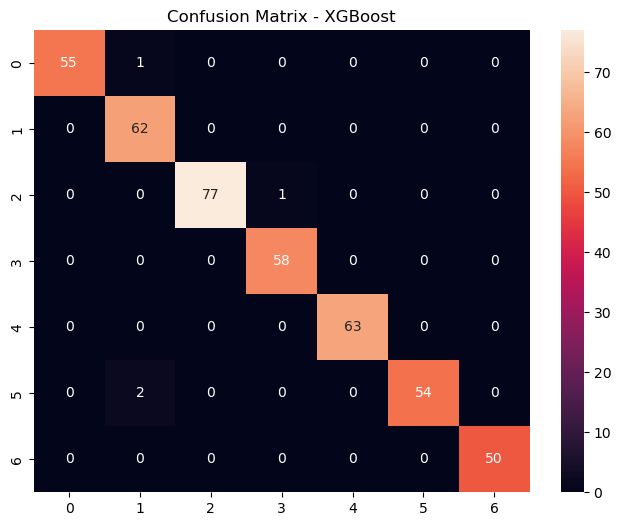

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred_final)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.show()

# Final Conclusion

Among all models, XGBoost achieved the highest accuracy (~99%) 
with minimal overfitting. It effectively captures
complex relationships between features,
making it the best model for predicting obesity levels.

# Feature Importance

In [61]:
import pandas as pd

xgb_model = pipe_xgb.named_steps['xgbclassifier']
feature_names = pipe_xgb.named_steps['columntransformer'].get_feature_names_out()

importances = xgb_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10)

num__BMI                                   0.263711
cat__Gender_Male                           0.142862
cat__CAEC_Frequently                       0.083278
cat__CAEC_Sometimes                        0.080219
cat__MTRANS_Walking                        0.079299
cat__CAEC_no                               0.051520
cat__CALC_Frequently                       0.050650
cat__family_history_with_overweight_yes    0.050139
num__FCVC                                  0.026375
num__NCP                                   0.020504
dtype: float32

In [63]:
import pickle

pickle.dump(pipe_xgb, open("model.pkl", "wb"))

In [70]:
import sklearn 
print(sklearn.__version__)

1.6.1


In [71]:
import joblib
print(joblib.__version__)

1.4.2


In [68]:
import joblib
joblib.dump(pipe_xgb, "bestmodel.pkl")

['bestmodel.pkl']

In [69]:
import joblib

joblib.dump(pipe_xgb, "bestmodel.pkl")

['bestmodel.pkl']